In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import netCDF4 as nc
import xarray as xr
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.dates as mdates

import sys
sys.path.append("functions") 
from functions import latte, axis_ratio_from_Q, tangential_velocity, out_core_param_fit, model_uv_at_xy, vector_R2


### Drifter Data

In [2]:
drifter_path = 'data/drifter_data.nc'

drifter_dataset = nc.Dataset(drifter_path, mode='r')

u_drif, v_drif = drifter_dataset['ve'][:].data, drifter_dataset['vn'][:].data
lon_drif, lat_drif = drifter_dataset['longitude'][:].data, drifter_dataset['latitude'][:].data
ID_drif =  drifter_dataset['ID'][:]
secs = drifter_dataset['time'][:].data
tim_drif = [datetime.utcfromtimestamp(t).strftime('%Y-%m-%d %H:%M:%S') for t in secs]
df_drifters = pd.DataFrame({'ID': ID_drif.astype(int), 'Lon': lon_drif, 'Lat': lat_drif, 'u': u_drif, 'v': v_drif, 'time': tim_drif})
df_drifters['time'] = pd.to_datetime(df_drifters['time'])
df_drifters = df_drifters[np.hypot(df_drifters.u, df_drifters.v) < 100]
df_drifters = df_drifters.reset_index().drop(columns=['index'])
df_drifters = df_drifters[df_drifters.time < pd.Timestamp('2024-02-10 00:00:00')]

theta_mean, phi_mean = np.float64(154.3), np.float64(-37.9)
df_drifters['x'] = (df_drifters.Lon - theta_mean) * 111000 * np.cos(np.deg2rad(phi_mean))
df_drifters['y'] = (df_drifters.Lat - phi_mean) * 111000

df_drifters = df_drifters[df_drifters.time <= np.datetime64('2024-01-27T06:00:00.000000000')]

df_drifters.head()


,ID,Lon,Lat,u,v,time,x,y
0,300534062034380,153.975,-37.651,0.39605,0.45606,2023-10-19 12:00:00,-28466.208360,27639.0
1,300534062034380,154.095,-37.579,0.47131,0.32648,2023-10-19 18:00:00,-17955.608350,35631.0
2,300534062034380,154.206,-37.523,0.47029,0.15047,2023-10-20 00:00:00,-8233.303341,41847.0
3,300534062034380,154.325,-37.520,0.49572,-0.06028,2023-10-20 06:00:00,2189.708335,42180.0
4,300534062034380,154.448,-37.547,0.45842,-0.19557,2023-10-20 12:00:00,12963.073346,39183.0


In [3]:
# Find inner-core ESP parameters from just the drifter data
start = df_drifters.time.min() + pd.Timedelta(days=1)
end   = df_drifters.time.max() - pd.Timedelta(days=1)
times = pd.date_range(start, end, freq="D")

T  = df_drifters["time"].to_numpy()
XY = df_drifters[["x","y"]].to_numpy()
UV = df_drifters[["u","v"]].to_numpy()
ID = df_drifters["ID"].to_numpy()

results = []
dic_drif = {}

for t in times:
    m = (T >= (t - pd.Timedelta(days=1))) & (T <= (t + pd.Timedelta(days=1)))
    xi, yi = XY[m].T
    ui, vi = UV[m].T

    dic_drif[t] = pd.DataFrame(
        {"xi": xi, "yi": yi, "ui": ui, "vi": vi, "ID": ID[m]}
    )

    xc, yc, w, Q, Omega, r2_latte = latte(xi, yi, ui, vi)
    results.append({"xc": xc, "yc": yc, "w": w, "Q": Q, "Omega": Omega, "r2_latte": r2_latte, "time": t})

df_drif_res = pd.DataFrame(results)
df_drif_res["alpha"] = [axis_ratio_from_Q(Q) for Q in df_drif_res["Q"].to_list()]
df_drif_res


,xc,yc,w,Q,Omega,r2_latte,time,alpha
0,-3294.287927,-5573.143352,-0.000027,"[[1.263598260460985, -0.10707400872727149], [-...",-0.000013,0.991515,2023-10-20 12:00:00,1.287155
1,1945.671980,-1983.946961,-0.000031,"[[1.3293208086036123, -0.04500609510622688], [...",-0.000015,0.980386,2023-10-21 12:00:00,1.332819
2,-5712.588428,-4674.576006,-0.000031,"[[1.0579383857758025, 0.05131669545893095], [0...",-0.000015,0.959225,2023-10-22 12:00:00,1.078132
3,-11550.619818,-7158.844551,-0.000033,"[[1.0271745315316416, 0.12584982527439253], [0...",-0.000016,0.928635,2023-10-23 12:00:00,1.135361
4,-12920.830789,-1271.000510,-0.000032,"[[1.0737560405562327, -0.051220084976039734], ...",-0.000016,0.916079,2023-10-24 12:00:00,1.090494
...,...,...,...,...,...,...,...,...
93,-271283.693810,122565.830319,-0.000037,"[[0.847776363898925, -0.10183981599000368], [-...",-0.000018,0.926633,2024-01-21 12:00:00,1.219677
94,-274003.762138,120987.483563,-0.000044,"[[0.777823367966188, -0.044042050467609305], [...",-0.000022,0.883714,2024-01-22 12:00:00,1.291906
95,-279345.230168,116538.045151,-0.000035,"[[0.802857214042767, -0.08252352665242936], [-...",-0.000017,0.932381,2024-01-23 12:00:00,1.268654
96,-282902.315609,115304.361195,-0.000035,"[[0.7112393963647362, -0.02199524398018189], [...",-0.000016,0.960400,2024-01-24 12:00:00,1.407372


### Satellite Data

In [4]:
ssh_path = 'data/satellite_data.nc'
ds_nc = nc.Dataset(ssh_path)

lon, lat = ds_nc['LONGITUDE'][:].data, ds_nc['LATITUDE'][:].data
u, v = ds_nc['UCUR'][:].data, ds_nc['VCUR'][:].data

t = pd.Timestamp("1985-01-01 00:00:00", tz="UTC") + pd.to_timedelta(ds_nc['TIME'][:].data, "D")
t = pd.DatetimeIndex(t).tz_convert(None)

u, v = np.where(np.abs(u) < 4.9, u, np.nan), np.where(np.abs(v) < 4.9, v, np.nan)

ds = xr.Dataset(
    {"u": (("time","lat","lon"), u), "v": (("time","lat","lon"), v)},
    coords={"time": t, "lat": lat, "lon": lon},
)

theta_mean, phi_mean = np.float64(154.3), np.float64(-37.9)
lon2d, lat2d = np.meshgrid(lon, lat)
ds = ds.assign_coords(
    x=(("lat","lon"), (lon2d-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))),
    y=(("lat","lon"), (lat2d-phi_mean)*111000),
)

t0, t1 = ds.time.to_index()[0], ds.time.to_index()[-1]
start = t0.normalize() + pd.Timedelta(hours=6) + pd.Timedelta(days=int(t0 > t0.normalize() + pd.Timedelta(hours=6)))
end   = t1.normalize() + pd.Timedelta(hours=6) - pd.Timedelta(days=int(t1 < t1.normalize() + pd.Timedelta(hours=6)))
t6am = pd.date_range(start, end, freq="1D")

ds_sat = ds.interp(time=t6am)

# Find land mask
land_mask = np.isnan(ds.u.isel(time=0)) & np.isnan(ds.v.isel(time=0))  # (lat, lon)
ds = ds.assign(land_mask=land_mask)
ds_sat = ds_sat.assign(land_mask=land_mask)

# # Time slice
ds_sat = ds_sat.sel(time=ds_sat.time <= np.datetime64('2024-01-27T06:00:00.000000000'))

ds_sat


<xarray.Dataset> Size: 3MB
Dimensions:    (time: 101, lat: 41, lon: 46)
Coordinates:
  * lat        (lat) float64 328B -42.0 -41.8 -41.6 -41.4 ... -34.4 -34.2 -34.0
  * lon        (lon) float64 368B 149.0 149.2 149.4 149.6 ... 157.6 157.8 158.0
    x          (lat, lon) float64 15kB -4.642e+05 -4.467e+05 ... 3.241e+05
    y          (lat, lon) float64 15kB -4.551e+05 -4.551e+05 ... 4.329e+05
  * time       (time) datetime64[ns] 808B 2023-10-19T06:00:00 ... 2024-01-27T...
Data variables:
    u          (time, lat, lon) float64 2MB -0.165 -0.2501 ... 0.2664 0.3238
    v          (time, lat, lon) float64 2MB -0.1421 -0.1373 ... -0.4036 -0.314
    land_mask  (lat, lon) bool 2kB False False False False ... False False False

## Multi-platform LATTE application

#### Calculate inner-core ESP parameters

In [5]:
xc_pre, yc_pre = 0.0, 0.0
q11, q12, q22 = 1.0, 0.0, 1.0

rows = []
xyuv_rows = []

X = ds_sat.x.values
Y = ds_sat.y.values
xg = X.ravel()
yg = Y.ravel()

T_drif = df_drifters["time"].to_numpy()
rho_core = 35_000.0
dt = pd.Timedelta(days=1)  # ±1 day

flag = True
for time in ds_sat.time.values:
    ut = ds_sat.u.sel(time=time).values.ravel()
    vt = ds_sat.v.sel(time=time).values.ravel()

    m = (T_drif >= (time - dt)) & (T_drif <= (time + dt))
    dfm = df_drifters.iloc[np.flatnonzero(m)]
    xd = dfm["x"].to_numpy()
    yd = dfm["y"].to_numpy()
    ud = dfm["u"].to_numpy()
    vd = dfm["v"].to_numpy()
    
    xi = np.concatenate([xd, xg])
    yi = np.concatenate([yd, yg])
    ui = np.concatenate([ud, ut])
    vi = np.concatenate([vd, vt])

    ########## Approxiamte inner-core data from previous day ############################
    dx = xi - xc_pre
    dy = yi - yc_pre
    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy
    core = rho2 <= rho_core**2
    xc, yc, w, Q, Omega, r2_latte = latte(xi[core], yi[core], ui[core], vi[core])
    ###############################################################################

    ########## Reapproximate inner-core parameters with more accurate core data #############
    xc_pre, yc_pre = xc, yc
    dx = xi - xc_pre
    dy = yi - yc_pre
    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy
    core = rho2 <= rho_core**2
    xc, yc, w, Q, Omega, r2_latte = latte(xi[core], yi[core], ui[core], vi[core])
    ###############################################################################

    xyuv_rows.append(pd.DataFrame({
        "time": time,
        "core": "inner",
        "xi": xi[core], "yi": yi[core], "ui": ui[core], "vi": vi[core]
    }))

    if np.isfinite(xc) and np.isfinite(yc) and (np.hypot(xc-xc_pre, yc-yc_pre) < 100_000) and (w < 0):
        rows.append(dict(xc=xc, yc=yc, w=w, Q=Q, Omega=Omega, r2=r2_latte, time=time))
        xc_pre, yc_pre = xc, yc
        q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]   # update deformation metric for next step
    else:
        break
df_xyuv = pd.concat(xyuv_rows, ignore_index=True) if xyuv_rows else pd.DataFrame(
    columns=["time","core","xi","yi","ui","vi"]
)
df_multimodal_res = pd.DataFrame(rows, columns=["xc","yc","w","Q","Omega","time"])
df_multimodal_res["alpha"] = [axis_ratio_from_Q(Q) for Q in df_multimodal_res["Q"].to_list()]
df_multimodal_res


,xc,yc,w,Q,Omega,time,alpha
0,3675.649550,5440.328473,-0.000030,"[[1.2156421394730985, 0.011082508899898064], [...",-0.000015,2023-10-19 06:00:00,1.215954
1,3960.719821,4947.833115,-0.000032,"[[1.2313291225386918, 0.0723584504225181], [0....",-0.000016,2023-10-20 06:00:00,1.243585
2,3489.788395,5262.281371,-0.000032,"[[1.2239955324284817, 0.06314285628024378], [0...",-0.000016,2023-10-21 06:00:00,1.233640
3,1366.561319,4343.255427,-0.000029,"[[1.1648244596264397, -0.026497196275960387], ...",-0.000014,2023-10-22 06:00:00,1.167104
4,-3613.979270,538.334160,-0.000030,"[[1.1902034304125704, 0.009181036767888335], [...",-0.000015,2023-10-23 06:00:00,1.190444
...,...,...,...,...,...,...,...
96,-277170.817225,115959.452337,-0.000028,"[[0.8862228595263886, -0.19918238034406702], [...",-0.000014,2024-01-23 06:00:00,1.275157
97,-277303.233579,118153.726429,-0.000026,"[[0.8612266788375906, -0.18597612950506726], [...",-0.000013,2024-01-24 06:00:00,1.283250
98,-276036.683134,119315.200664,-0.000024,"[[0.8309239081483935, -0.23611062094628232], [...",-0.000012,2024-01-25 06:00:00,1.373348
99,-286477.983239,111173.543202,-0.000027,"[[0.7846175417780489, 0.05888541432806866], [0...",-0.000013,2024-01-26 06:00:00,1.285844


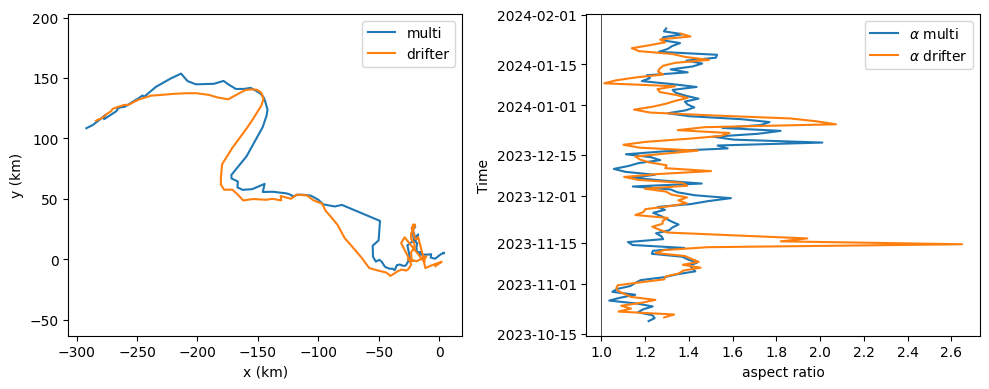

In [6]:
# quick comparison between multi-paltform and drifter results
fig, axs = plt.subplots(1, 2, figsize=(10,4), sharey=False)
axs[0].plot(df_multimodal_res.xc/1e3, df_multimodal_res.yc/1e3, label='multi');
axs[0].plot(df_drif_res.xc/1e3, df_drif_res.yc/1e3, label='drifter'); axs[0].axis('equal')
axs[0].set_xlabel('x (km)'); axs[0].set_ylabel('y (km)'); axs[0].legend()

axs[1].plot(df_multimodal_res.alpha, df_multimodal_res.time, label=r'$\alpha$ multi')
axs[1].plot(df_drif_res.alpha, df_drif_res.time, label=r'$\alpha$ drifter')
axs[1].set_xlabel('aspect ratio'); axs[1].set_ylabel('Time')
axs[1].legend(); axs[1].axvline(1, lw=.5, color='k')
plt.tight_layout()


(np.float64(-341974.94824870146),
 np.float64(51795.33423609838),
 np.float64(-46730.99576568606),
 np.float64(199910.9110794066))

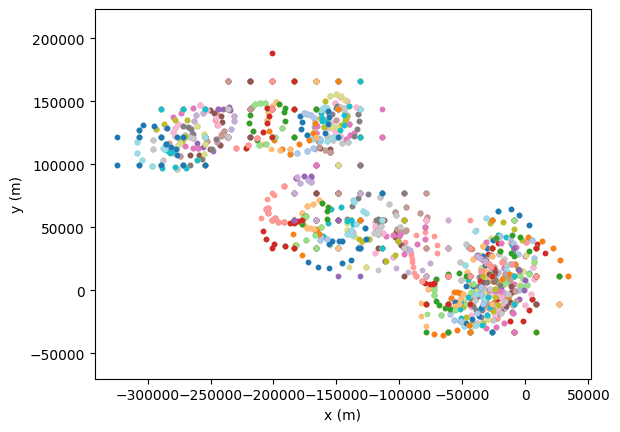

In [7]:
# Inner-core mutli-platform data used 
cmap = plt.colormaps['tab20']
for t, time in enumerate(df_xyuv.time.unique()):
    df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == 'inner')]
    plt.scatter(df.xi, df.yi, s=10, color=cmap(t % cmap.N))
plt.xlabel('x (m)'); plt.ylabel('y (m)')
plt.axis('equal')


#### Calculate outer-core ESP parameters

,xc,yc,w,Q,Omega,time,alpha,Rc,psi0
0,3675.649550,5440.328473,-0.000033,"[[1.2156421394730985, 0.011082508899898064], [...",-0.000016,2023-10-19 06:00:00,1.215954,88930.036943,63728.871958
1,3960.719821,4947.833115,-0.000034,"[[1.2313291225386918, 0.0723584504225181], [0....",-0.000017,2023-10-20 06:00:00,1.243585,87323.214405,63058.080335
2,3489.788395,5262.281371,-0.000034,"[[1.2239955324284817, 0.06314285628024378], [0...",-0.000017,2023-10-21 06:00:00,1.233640,86800.975876,63519.252708
3,1366.561319,4343.255427,-0.000033,"[[1.1648244596264397, -0.026497196275960387], ...",-0.000016,2023-10-22 06:00:00,1.167104,88179.974720,62534.038226
4,-3613.979270,538.334160,-0.000032,"[[1.1902034304125704, 0.009181036767888335], [...",-0.000016,2023-10-23 06:00:00,1.190444,87178.902772,59922.546729
...,...,...,...,...,...,...,...,...,...
96,-277170.817225,115959.452337,-0.000025,"[[0.8862228595263886, -0.19918238034406702], [...",-0.000012,2024-01-23 06:00:00,1.275157,76259.987414,35762.044310
97,-277303.233579,118153.726429,-0.000025,"[[0.8612266788375906, -0.18597612950506726], [...",-0.000012,2024-01-24 06:00:00,1.283250,77957.544413,36419.475808
98,-276036.683134,119315.200664,-0.000023,"[[0.8309239081483935, -0.23611062094628232], [...",-0.000011,2024-01-25 06:00:00,1.373348,79729.058979,35176.183998
99,-286477.983239,111173.543202,-0.000023,"[[0.7846175417780489, 0.05888541432806866], [0...",-0.000011,2024-01-26 06:00:00,1.285844,80348.998312,36392.127018


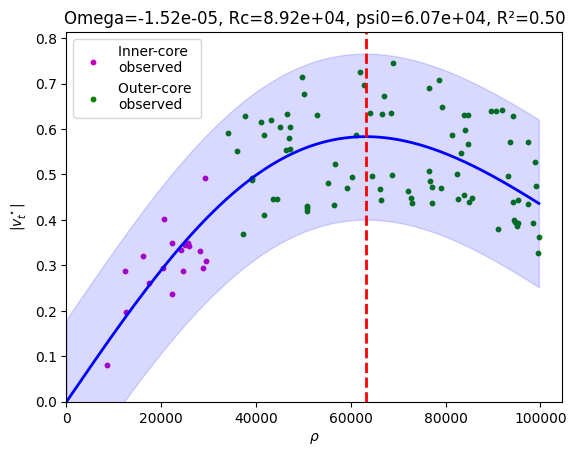

In [8]:
rho_outer = 100_000.0
dic_outer_mask_data = {}

Rc_opts, psi0_opts, Omega_opts = [], [], []
xyuv_rows = []

for k in range(len(df_multimodal_res)):
    data = df_multimodal_res.iloc[k]
    time = data.time  # or data.Time if that's your column

    ut = ds_sat.u.sel(time=time).values.ravel()
    vt = ds_sat.v.sel(time=time).values.ravel()

    m = (df_drifters["time"].to_numpy() >= (time - dt)) & (df_drifters["time"].to_numpy() <= (time + dt))
    dfm = df_drifters.iloc[np.flatnonzero(m)]
    xd, yd = dfm["x"].to_numpy(), dfm["y"].to_numpy()
    ud, vd = dfm["u"].to_numpy(), dfm["v"].to_numpy()

    xi = np.concatenate([xd, xg])
    yi = np.concatenate([yd, yg])
    ui = np.concatenate([ud, ut])
    vi = np.concatenate([vd, vt])

    xc, yc, Q, Omega = float(data.xc), float(data.yc), np.asarray(data.Q), float(data.Omega)
    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

    dx = xi - xc
    dy = yi - yc
    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy

    outer = rho2 <= rho_outer**2
    xi_o, yi_o, ui_o, vi_o = xi[outer], yi[outer], ui[outer], vi[outer]
    dx_o, dy_o, rho2_o = dx[outer], dy[outer], rho2[outer]

    xyuv_rows.append(pd.DataFrame({
        "time": time, "core": "outer",
        "xi": xi_o, "yi": yi_o, "ui": ui_o, "vi": vi_o
    }))

    vt_o = tangential_velocity(xi_o, yi_o, ui_o, vi_o, xc, yc, Q)
    Qr_o = np.sqrt((Q[0,0]*dx_o + Q[1,0]*dy_o)**2 + (Q[1,0]*dx_o + Q[1,1]*dy_o)**2)

    sign_mask = (vt_o <= 0) if (Omega < 0) else (vt_o >= 0)
    rho2_f, Qr_f, vt_f = rho2_o[sign_mask], Qr_o[sign_mask], vt_o[sign_mask]

    Rc_opt, psi0_opt, Omega_opt = out_core_param_fit(rho2_f, Qr_f, vt_f, Omega0=Omega, plot=(k == 10), pred_flag=True)
    Rc_opts.append(Rc_opt); psi0_opts.append(psi0_opt); Omega_opts.append(Omega_opt)

df_xyuv_o = pd.concat(xyuv_rows, ignore_index=True) if xyuv_rows else pd.DataFrame(
    columns=["time","core","xi","yi","ui","vi"]
)

df_xyuv = pd.concat([df_xyuv, df_xyuv_o], ignore_index=True)
df_xyuv = (
    df_xyuv
    .sort_values(by="core", key=lambda s: s.eq("outer"))  # keep inner first
    .drop_duplicates(subset=["time", "xi", "yi", "ui", "vi"], keep="first")
    .reset_index(drop=True)
)

df_multimodal_res["Rc"] = Rc_opts
df_multimodal_res["psi0"] = psi0_opts
df_multimodal_res["Omega"] = Omega_opts
df_multimodal_res["w"] = [Omega*(Q[0,0] + Q[1,1]) for (Omega,Q) in zip(df_multimodal_res.Omega, df_multimodal_res.Q)]
df_multimodal_res


In [9]:
# Find R2
R2_vals = []
for _, row in df_multimodal_res.iterrows():
    df = df_xyuv[df_xyuv.time == row.time]
    xi = df.xi.to_numpy(float)
    yi = df.yi.to_numpy(float)
    u  = df.ui.to_numpy(float)
    v  = df.vi.to_numpy(float)
    uhat, vhat = model_uv_at_xy(xi, yi, row.xc, row.yc, np.asarray(row.Q), row.Omega, row.Rc)
    R2_vals.append(vector_R2(u, v, uhat, vhat))
df_multimodal_res['R2'] = R2_vals
df_multimodal_res


,xc,yc,w,Q,Omega,time,alpha,Rc,psi0,R2
0,3675.649550,5440.328473,-0.000033,"[[1.2156421394730985, 0.011082508899898064], [...",-0.000016,2023-10-19 06:00:00,1.215954,88930.036943,63728.871958,0.965234
1,3960.719821,4947.833115,-0.000034,"[[1.2313291225386918, 0.0723584504225181], [0....",-0.000017,2023-10-20 06:00:00,1.243585,87323.214405,63058.080335,0.968288
2,3489.788395,5262.281371,-0.000034,"[[1.2239955324284817, 0.06314285628024378], [0...",-0.000017,2023-10-21 06:00:00,1.233640,86800.975876,63519.252708,0.968203
3,1366.561319,4343.255427,-0.000033,"[[1.1648244596264397, -0.026497196275960387], ...",-0.000016,2023-10-22 06:00:00,1.167104,88179.974720,62534.038226,0.962805
4,-3613.979270,538.334160,-0.000032,"[[1.1902034304125704, 0.009181036767888335], [...",-0.000016,2023-10-23 06:00:00,1.190444,87178.902772,59922.546729,0.935408
...,...,...,...,...,...,...,...,...,...,...
96,-277170.817225,115959.452337,-0.000025,"[[0.8862228595263886, -0.19918238034406702], [...",-0.000012,2024-01-23 06:00:00,1.275157,76259.987414,35762.044310,0.758715
97,-277303.233579,118153.726429,-0.000025,"[[0.8612266788375906, -0.18597612950506726], [...",-0.000012,2024-01-24 06:00:00,1.283250,77957.544413,36419.475808,0.736041
98,-276036.683134,119315.200664,-0.000023,"[[0.8309239081483935, -0.23611062094628232], [...",-0.000011,2024-01-25 06:00:00,1.373348,79729.058979,35176.183998,0.762413
99,-286477.983239,111173.543202,-0.000023,"[[0.7846175417780489, 0.05888541432806866], [0...",-0.000011,2024-01-26 06:00:00,1.285844,80348.998312,36392.127018,0.665855


(np.float64(-417796.0563692059),
 np.float64(102478.05606926142),
 np.float64(-117659.91954803483),
 np.float64(273060.17360687244))

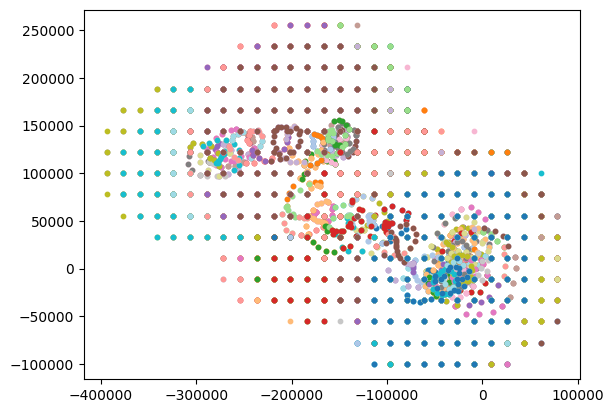

In [10]:
# Outer-core mutli-platform data used 
cmap = plt.colormaps['tab20']
for t, time in enumerate(df_xyuv.time.unique()):
    df = df_xyuv[(df_xyuv.time == time)]
    plt.scatter(df.xi, df.yi, s=10, color=cmap(t % cmap.N))

plt.axis('equal')


In [11]:
# Reconstruct velocity field using ESP parameters
X = ds_sat.x.values
Y = ds_sat.y.values
nt = len(df_multimodal_res)

U = np.empty((nt, X.shape[0], X.shape[1]))
V = np.empty((nt, X.shape[0], X.shape[1]))

for k in range(nt):
    data = df_multimodal_res.iloc[k]

    dx = X - data.xc
    dy = Y - data.yc

    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]

    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
    fac = data.Omega * np.exp(-rho2 / data.Rc**2)

    U[k] = -fac * (q12*dx + q22*dy)
    V[k] =  fac * (q11*dx + q12*dy)

mask = ds_sat.land_mask.values[None, :, :]   # (1, lat, lon)
U = np.where(mask, np.nan, U)
V = np.where(mask, np.nan, V)

ds_model = xr.Dataset(
    data_vars=dict(
        u=(("time","lat","lon"), U),
        v=(("time","lat","lon"), V),
    ),
    coords=dict(
        time=df_multimodal_res.time.values,
        lat=ds_sat.lat.values,
        lon=ds_sat.lon.values,
        x=(("lat","lon"), X),
        y=(("lat","lon"), Y),
    ),
)


In [12]:
def plot_model(df_res, ds_sat, ds_model, df_xyuv, df_drifters, time=None, spac=1, scale=20,
                xlim=(-410, 200), ylim=(-160, 260), plot_data=False):

    if time is None:
        time = ds_model.time.values[0]

    sat = ds_sat.sel(time=time, method="nearest")
    mod = ds_model.sel(time=time, method="nearest")
    data = df_res[df_res.time == time].iloc[0]

    X = sat.x.values / 1e3
    Y = sat.y.values / 1e3

    us, vs = sat.u.values, sat.v.values
    um, vm = mod.u.values, mod.v.values

    sp_s = np.hypot(us, vs)
    sp_m = np.hypot(um, vm)

    dx = sat.x.values - data.xc
    dy = sat.y.values - data.yc
    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]
    rho2_grid = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

    roi = (X >= xlim[0]) & (X <= xlim[1]) & (Y >= ylim[0]) & (Y <= ylim[1])
    sp_s_roi = np.where(roi, sp_s, np.nan)
    sp_m_roi = np.where(roi, sp_m, np.nan)
    roi_quiv = roi & (rho2_grid >= 100_000**2)

    vals = np.concatenate([sp_s_roi[roi], sp_m_roi[roi]])
    vmax = np.nanmax(vals)
    levels = np.arange(0, vmax + .05, .05)

    X_rho, Y_rho = np.meshgrid(np.linspace(xlim[0]*1e3, xlim[1]*1e3, 100),
                               np.linspace(ylim[0]*1e3, ylim[1]*1e3, 100))
    dx = X_rho - data.xc
    dy = Y_rho - data.yc
    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

    fig, axs = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True, constrained_layout=True)

    # ----- coloured center path -----
    x_path = df_res.xc.to_numpy() / 1e3
    y_path = df_res.yc.to_numpy() / 1e3
    t_path = pd.to_datetime(df_res.time)
    t_num = mdates.date2num(t_path)

    pts = np.array([x_path, y_path]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)

    norm_t = Normalize(t_num.min(), t_num.max())
    lc0 = LineCollection(segs, cmap="plasma", norm=norm_t, linewidth=2, zorder=2)
    lc0.set_array(t_num[:-1])

    lc1 = LineCollection(segs, cmap="plasma", norm=norm_t, linewidth=2, zorder=2)
    lc1.set_array(t_num[:-1])

    # ---- Satellite ----
    h0 = axs[0].contourf(X, Y, sp_s_roi, levels=levels, cmap="Blues_r")

    axs[0].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi_quiv[::spac,::spac], us[::spac,::spac], np.nan),
                  np.where(roi_quiv[::spac,::spac], vs[::spac,::spac], np.nan),
                  scale=scale, width=.0015, alpha=.4)

    axs[0].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50, zorder=3)
    axs[0].add_collection(lc0)
    axs[0].contour(X_rho/1e3, Y_rho/1e3, rho2,
                   levels=[(data.Rc**2)/2], colors="r", linewidths=2,
                   zorder=3, linestyles='--')

    if plot_data:
        df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == 'outer')]
        axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi,
                      scale=scale, width=.0025, color='g',
                      label='Outer-core data', zorder=2)
        df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == 'inner')]
        axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi,
                      scale=scale, width=.0025, color='m',
                      label='Inner-core data', zorder=2)

    for i, d in enumerate(df_drifters.ID.unique()):
        df = df_drifters[df_drifters.ID == d]
        axs[0].plot(df.x/1e3, df.y/1e3, zorder=1, lw=1, alpha=.5,
                    color='tab:pink' if i == 0 else 'tab:orange')

    # axs[0].set_title("Satellite")
    axs[0].set_aspect("equal")
    axs[0].legend(loc='lower left')

    # ---- Model ----
    h1 = axs[1].contourf(X, Y, sp_m_roi, levels=levels, cmap="Blues_r")
    axs[1].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi[::spac,::spac], um[::spac,::spac], np.nan),
                  np.where(roi[::spac,::spac], vm[::spac,::spac], np.nan),
                  scale=scale, alpha=.5, width=.0015)
    axs[1].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50,
                   label='Eddy center', zorder=3)
    axs[1].add_collection(lc1)
    axs[1].contour(X_rho/1e3, Y_rho/1e3, rho2,
                   levels=[(data.Rc**2)/2], colors="r", linewidths=2,
                   zorder=3, linestyles='--')
    axs[1].plot([np.nan, np.nan], [np.nan, np.nan], lw=2, color='r',
                label='Max tangential\nvelocity', ls='--')

    for i, d in enumerate(df_drifters.ID.unique()):
        df = df_drifters[df_drifters.ID == d]
        axs[1].plot(df.x/1e3, df.y/1e3, zorder=1, lw=1, alpha=.5,
                    color='tab:pink' if i == 0 else 'tab:orange',
                    label='Drifter 1' if i == 0 else 'Drifter 2')

    # axs[1].set_title("Model - LATTE with Drifter and Satellite Data")
    axs[1].set_aspect("equal")
    axs[1].legend(loc='lower left')

    gap = 20
    for ax in axs:
        ax.set_xlim(xlim[0] + gap, xlim[1] - gap)
        ax.set_ylim(ylim[0] + gap, ylim[1] - gap)
        ax.set_xlabel("x (km)")
    axs[0].set_ylabel("y (km)")

    axs[0].text(-0.05, 1.05, "a)", transform=axs[0].transAxes, fontsize=13,
                fontweight="bold", va="top", ha="left")
    axs[1].text(-0.05, 1.05, "b)", transform=axs[1].transAxes, fontsize=13,
                fontweight="bold", va="top", ha="left")

    # speed colourbar
    fig.colorbar(h1, ax=axs, label="Current speed (m s$^{-1}$)", fraction=0.0165, pad=0.02)

    # time colourbar
    cbar2 = fig.colorbar(lc1, ax=axs, fraction=0.0165, pad=0.025)
    cbar2.set_label("Center path time")
    cbar2.ax.yaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))

    plt.show()


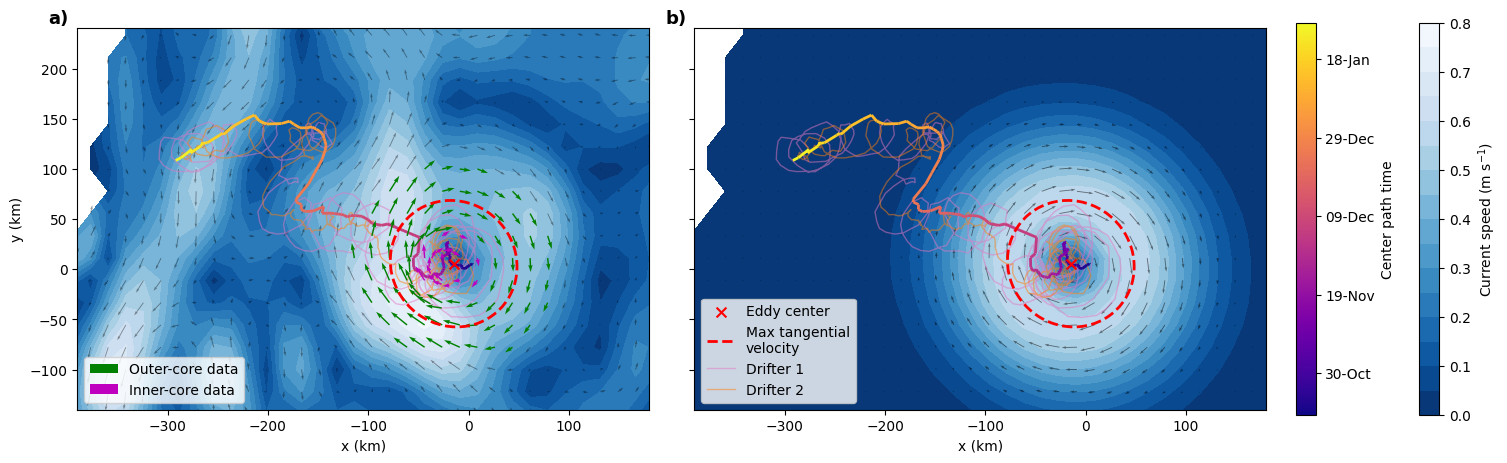

In [13]:
plot_model(df_multimodal_res, ds_sat, ds_model, df_xyuv, df_drifters, time=df_multimodal_res.time.values[10], plot_data=True)


In [14]:
# Results
df_paper = df_multimodal_res.copy()
df_paper = df_paper.drop(columns='Q')
df_paper.loc[np.arange(0, 100, 10)]


,xc,yc,w,Omega,time,alpha,Rc,psi0,R2
0,3675.649550,5440.328473,-0.000033,-0.000016,2023-10-19 06:00:00,1.215954,88930.036943,63728.871958,0.965234
10,-14852.249603,5545.961977,-0.000031,-0.000015,2023-10-29 06:00:00,1.049983,89235.229501,60672.786994,0.928488
20,-21796.338693,25423.214058,-0.000032,-0.000015,2023-11-08 06:00:00,1.438219,81577.952758,49757.389031,0.937130
30,-24336.880034,884.662621,-0.000030,-0.000015,2023-11-18 06:00:00,1.250007,92123.595328,62135.742142,0.909249
40,-44923.696630,-6127.738914,-0.000034,-0.000016,2023-11-28 06:00:00,1.410108,77462.228843,47555.839579,0.831244
50,-95981.750120,45516.545649,-0.000043,-0.000021,2023-12-08 06:00:00,1.244269,87733.728956,81125.290925,0.774679
60,-145989.186562,55752.439519,-0.000028,-0.000013,2023-12-18 06:00:00,1.531404,117923.757148,90233.948265,0.837114
70,-146060.014233,109326.114893,-0.000030,-0.000014,2023-12-28 06:00:00,1.402837,95768.563416,65603.037088,0.706877
80,-168119.997743,140911.634703,-0.000023,-0.000011,2024-01-07 06:00:00,1.435218,133694.239484,96579.707224,0.795530
90,-245361.726578,135563.245772,-0.000026,-0.000012,2024-01-17 06:00:00,1.523417,76077.420296,34384.645827,0.755299


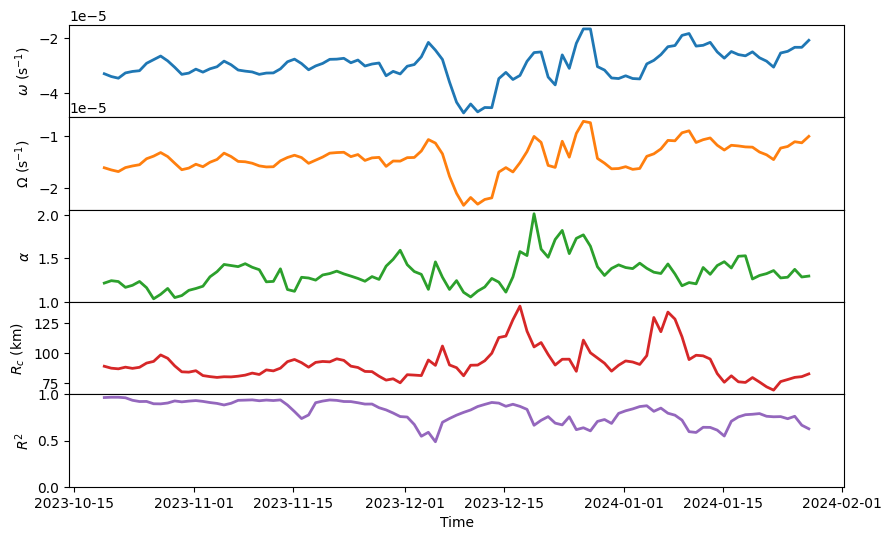

In [15]:
# Time series
clrs = plt.colormaps['tab10']
fig, axs = plt.subplots(5, 1, figsize=(10,6), sharex=True)
lw = 2

axs[0].plot(df_multimodal_res.time, df_multimodal_res.w, color=clrs(0), lw=lw)
axs[0].set_ylabel(r'$\omega$ (s$^{-1}$)')

axs[1].plot(df_multimodal_res.time, df_multimodal_res.Omega, color=clrs(1), lw=lw)
axs[1].set_ylabel(r'$\Omega$ (s$^{-1}$)')

axs[2].plot(df_multimodal_res.time, df_multimodal_res.alpha, color=clrs(2), lw=lw)
axs[2].set_ylabel(r'$\alpha$')
axs[2].set_ylim(1, None)

axs[3].plot(df_multimodal_res.time, df_multimodal_res.Rc/1e3, color=clrs(3), lw=lw)
axs[3].set_ylabel(r'$R_c$ (km)')

axs[4].plot(df_multimodal_res.time, df_multimodal_res.R2, color=clrs(4), lw=lw)
axs[4].set_ylabel(r'$R^2$')
axs[4].set_xlabel('Time')
axs[4].set_ylim(0,1)

fig.subplots_adjust(hspace=0)
